# Benchmarking of Stace-Space vs. Transfer-Function Backend [ex130.0]

This example demonstrates the usage of transfer-function (tf) backend in RLSAlssm* classes.
This is done for one single channel.


In [1]:
import timeit
import numpy as np
import matplotlib.pyplot as plt
import lmlib as lm

We surpress the warning for non-steady state filters.

We will execute each filter 2 times for timing purposes.

We will use the lfilter backend (IIR approach) and numpy backend (direct state space recursion) for comparison.

In [2]:
lm.WARNING_NOT_STEADY_STATE = False

n_exe = 2  # number of filter executions

# setting all recursions to JIT backend default
backends = ['numpy', 'lfilter']
mspsecs_dict = {k: [] for k in backends}

We set up a random signal of 1 million samples which we will approach with a polynomial ALSSM of order 1. The model will approximate at each sample the signal for 20 samples using forward recursion with exponential decay cost.

In [3]:
K = 1_000_000
y = np.random.randn(K)

# setup model
alssm = lm.AlssmPoly(poly_degree=1)
seg_l = lm.Segment(a=-21, b=-1, direction=lm.FW, g=100)
cost = lm.CompositeCost([alssm], [seg_l], F=[[1]])

Here we benchmark each backend (this normally should take around 1m30s).

In [4]:
# Single channel
for backend in backends:
    rls = lm.RLSAlssm(cost, backend=backend, steady_state=False, calc_W=False, calc_kappa=False, calc_nu=False)
    rls.filter(y)
    proc_time = timeit.timeit('rls.filter(y)', globals=globals(), number=n_exe)
    mspsec = K * n_exe * 1e-6 / proc_time
    mspsecs_dict[backend].append(mspsec)

### Visualization
We visualise the amount of samples that can be processed per second for each backend.

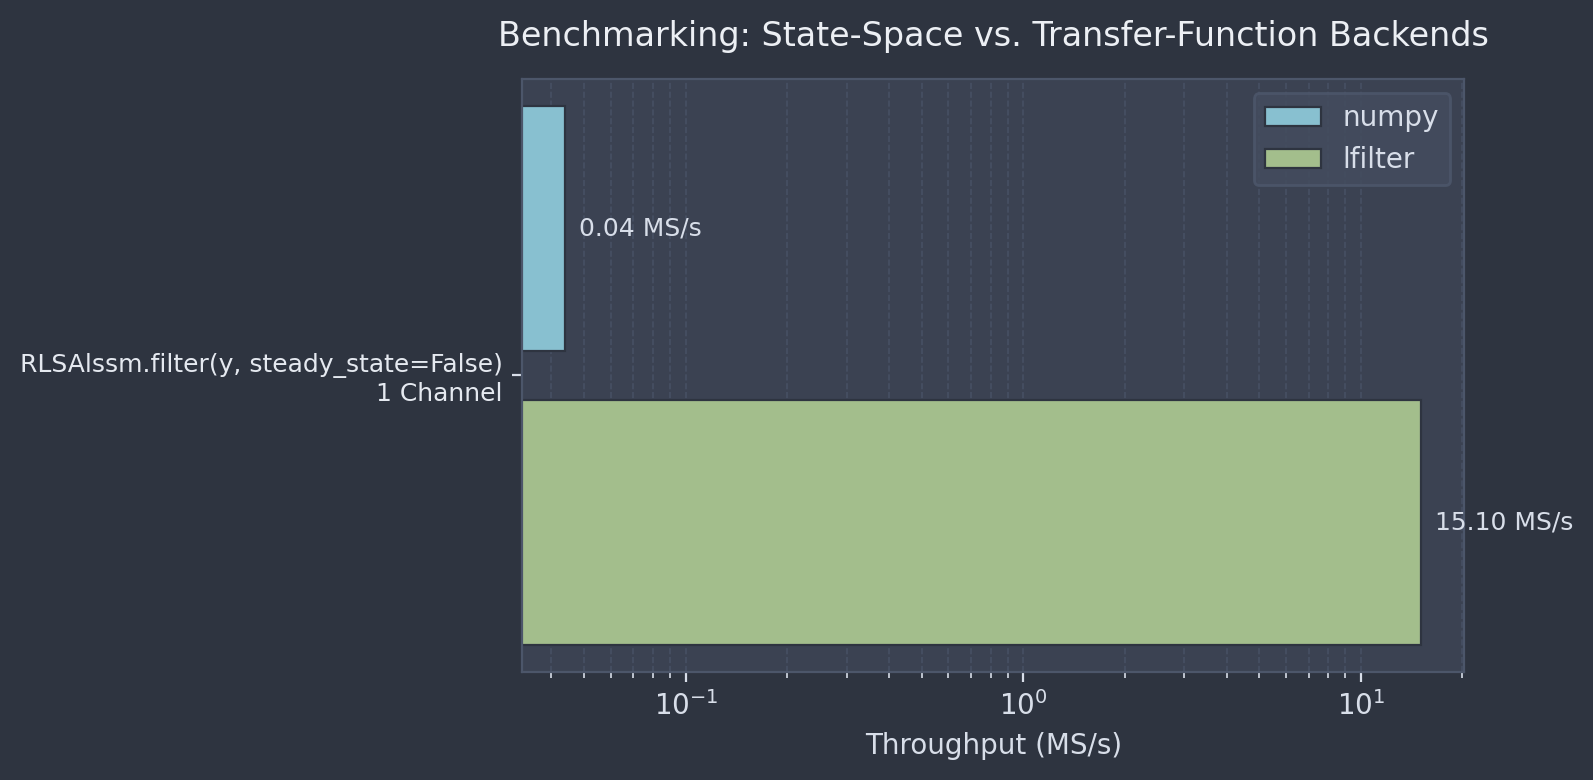

In [5]:
bar_colors = [lm.NORD['blue'], lm.NORD['green']]

labels = ('RLSAlssm.filter(y, steady_state=False)\n1 Channel',)
locs  = np.arange(len(labels))
width = 0.25   # bar thickness
gap   = 0.30   # spacing between bar centres (> width → visible gap)

fig, ax = plt.subplots(figsize=(8, 4), dpi=200)

# --- Styling ----------------------------------------------------------
fig.patch.set_facecolor(lm.NORD['bg'])
ax.set_facecolor(lm.NORD['bg2'])

for spine in ax.spines.values():
    spine.set_edgecolor(lm.NORD['border'])

ax.tick_params(colors=lm.NORD['fg'], which='both')
ax.xaxis.label.set_color(lm.NORD['fg'])
ax.yaxis.label.set_color(lm.NORD['fg'])
ax.title.set_color(lm.NORD['white'])
ax.set_xscale('log')
ax.xaxis.grid(True, color=lm.NORD['border'], linestyle='--', linewidth=0.6, alpha=0.7, which='both')
ax.set_axisbelow(True)
# ----------------------------------------------------------------------

for i, (backend, color) in enumerate(zip(backends, bar_colors)):
    rect_ = ax.barh(
        locs + gap * i,
        mspsecs_dict[backend],
        width,
        label=backend,
        color=color,
        edgecolor=lm.NORD['bg'],
        linewidth=0.8,
    )
    ax.bar_label(rect_, fmt="%.2f MS/s", padding=5, color=lm.NORD['fg'], fontsize=9)

ax.invert_yaxis()
ax.set_xlabel('Throughput (MS/s)', color=lm.NORD['fg'])
ax.set_title('Benchmarking: State-Space vs. Transfer-Function Backends', color=lm.NORD['white'], pad=12)
ax.set_yticks(locs + gap * (len(backends) - 1) / 2, labels, fontsize=9, color=lm.NORD['fg2'])

legend = ax.legend(facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'], labelcolor=lm.NORD['fg'], framealpha=0.9)

fig.tight_layout()
plt.show()
